# IPD Density Map - FIXED VERSION
## With MAE computed for each epoch during training

In [1]:
# Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importing dependencies
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import scipy.io
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# Loading dataset
DATA_PATH = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech"

print("Dataset root exists:", os.path.exists(DATA_PATH))
print("Folders:", os.listdir(DATA_PATH))

TRAIN_A = os.path.join(DATA_PATH, "part_A", "train_data", "images")
TEST_A  = os.path.join(DATA_PATH, "part_A", "test_data", "images")

TRAIN_B = os.path.join(DATA_PATH, "part_B", "train_data", "images")
TEST_B  = os.path.join(DATA_PATH, "part_B", "test_data", "images")

print("Train A images:", len(os.listdir(TRAIN_A)))
print("Test A images:", len(os.listdir(TEST_A)))

Dataset root exists: True
Folders: ['part_A', 'part_B']
Train A images: 300
Test A images: 182


In [4]:
def load_points(mat_path):
    mat = scipy.io.loadmat(mat_path)
    # ShanghaiTech annotation format
    points = mat["image_info"][0][0][0][0][0]
    return points

def generate_density_map(image, points, sigma=4):
    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for p in points:
        x = min(w-1, int(p[0]))
        y = min(h-1, int(p[1]))
        density[y, x] = 1
    density = gaussian_filter(density, sigma)
    return density

In [5]:
class ShanghaiTechDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_paths = sorted(
            glob.glob(os.path.join(image_folder, "*.jpg"))
        )

        # Construct GT paths safely
        self.gt_paths = []
        for img_path in self.image_paths:
            filename = os.path.basename(img_path)        # IMG_42.jpg
            mat_name = "GT_" + filename.replace(".jpg",".mat")
            gt_folder = os.path.join(
                os.path.dirname(os.path.dirname(img_path)),
                "ground-truth"
            )
            gt_path = os.path.join(gt_folder, mat_name)
            self.gt_paths.append(gt_path)

        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        gt_path  = self.gt_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        points = load_points(gt_path)
        density = generate_density_map(img, points)

        if self.transform:
            img = self.transform(img)

        density = torch.tensor(density).unsqueeze(0)

        return img, density

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = ShanghaiTechDataset(TRAIN_A, transform=transform)
test_dataset = ShanghaiTechDataset(TEST_A, transform=transform)

print("Total training images:", len(train_dataset))
print("Total test images:", len(test_dataset))

loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
for imgs, density in loader:
    print("Image shape:", imgs.shape)
    print("Density shape:", density.shape)
    print("Estimated Count:", density.sum(dim=[1,2,3]))
    break

Total training images: 300
Total test images: 182
Image shape: torch.Size([1, 3, 530, 1024])
Density shape: torch.Size([1, 1, 530, 1024])
Estimated Count: tensor([498.0000])


In [7]:
class PatchDataset(torch.utils.data.Dataset):
    """
    Returns:
        patch_img: Tensor [3,H,W]
        density_patch: Tensor [1,H,W]
        router_label: 0/1/2
    """
    def __init__(self, base_dataset, patch_size=128, stride=64):
        self.samples = []

        for img, density in base_dataset:
            _, H, W = img.shape

            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    patch_img = img[:, y:y+patch_size, x:x+patch_size]
                    density_patch = density[:, y:y+patch_size, x:x+patch_size]

                    # Router label based on density sum
                    count = density_patch.sum().item()
                    if count < 1:
                        label = 0  # empty
                    elif count < 10:
                        label = 1  # low density
                    else:
                        label = 2  # high density

                    self.samples.append((patch_img, density_patch, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        patch_img, density_patch, label = self.samples[idx]
        return patch_img, density_patch, torch.tensor(label)

In [8]:
train_patch_dataset = PatchDataset(train_dataset)
test_patch_dataset = PatchDataset(test_dataset)

train_patch_loader = DataLoader(train_patch_dataset, batch_size=32, shuffle=True)
test_patch_loader = DataLoader(test_patch_dataset, batch_size=32, shuffle=False)

print("Total training patch samples:", len(train_patch_dataset))
print("Total test patch samples:", len(test_patch_dataset))

labels = [label for _,_,label in train_patch_dataset.samples]
print("Training label distribution:", Counter(labels))

Total training patch samples: 31565
Total test patch samples: 18001
Training label distribution: Counter({2: 13308, 1: 11411, 0: 6846})


## Router Model Training

In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class Router(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = resnet18(weights=None)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

router = Router().to(device)

Using device: cuda


In [10]:
# Compute class weights from your patch dataset counts
labels = [label for _,_,label in train_patch_dataset.samples]
label_counter = Counter(labels)
class_counts = torch.tensor([label_counter[0], label_counter[1], label_counter[2]], dtype=torch.float, device=device)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

print("Class weights:", class_weights)

router_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
router_optimizer = torch.optim.Adam(router.parameters(), lr=1e-4)

Class weights: tensor([0.4730, 0.2837, 0.2433], device='cuda:0')


In [12]:
def train_router(loader, num_epochs=30, save_path="best_router.pth", patience=5):
    router.train()
    best_acc = 0.0
    epochs_no_improve = 0

    scaler = torch.amp.GradScaler("cuda")

    for epoch in range(1, num_epochs + 1):
        total_loss = 0
        correct = 0
        total = 0

        for imgs, _, labels in tqdm(loader, desc=f"Epoch {epoch}/{num_epochs}"):

            imgs = imgs.to(device)
            labels = labels.to(device)

            router_optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                logits = router(imgs)
                loss = router_loss_fn(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(router_optimizer)
            scaler.update()

            total_loss += loss.item() * imgs.size(0)

            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += imgs.size(0)

        avg_loss = total_loss / total
        acc = correct / total * 100

        print(f"Epoch {epoch:02d}: Router Loss = {avg_loss:.4f}, Accuracy = {acc:.2f}%")

        # save best model
        if acc > best_acc:
            best_acc = acc
            epochs_no_improve = 0
            torch.save(router.state_dict(), save_path)
            print(f"✓ Best router saved with Acc = {best_acc:.2f}%")

        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs")

        # early stopping
        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered")
            break

    print(f"\nTraining complete. Best accuracy: {best_acc:.2f}%")

In [13]:
train_router(train_patch_loader, num_epochs=30, patience=5)

Epoch 1/30: 100%|██████████| 987/987 [00:25<00:00, 39.05it/s]


Epoch 01: Router Loss = 0.0540, Accuracy = 98.03%
✓ Best router saved with Acc = 98.03%


Epoch 2/30: 100%|██████████| 987/987 [00:25<00:00, 39.01it/s]


Epoch 02: Router Loss = 0.0566, Accuracy = 97.89%
No improvement for 1 epochs


Epoch 3/30: 100%|██████████| 987/987 [00:24<00:00, 39.67it/s]


...

Epoch 20: Router Loss = 0.0246, Accuracy = 99.14%
No improvement for 3 epochs


Epoch 21/30: 100%|██████████| 987/987 [00:25<00:00, 39.34it/s]


Epoch 21: Router Loss = 0.0206, Accuracy = 99.30%
No improvement for 4 epochs


Epoch 22/30: 100%|██████████| 987/987 [00:25<00:00, 39.24it/s]

Epoch 22: Router Loss = 0.0203, Accuracy = 99.27%
No improvement for 5 epochs

Early stopping triggered

Training complete. Best accuracy: 99.38%


In [14]:
import matplotlib.pyplot as plt

epochs = list(range(1,23))

loss = [
0.0540,0.0566,0.0468,0.0426,0.0409,0.0377,0.0361,0.0353,0.0337,0.0338,
0.0260,0.0279,0.0291,0.0252,0.0263,0.0277,0.0172,0.0272,0.0204,0.0246,
0.0206,0.0203
]

acc = [
98.03,97.89,98.40,98.51,98.44,98.69,98.73,98.69,98.80,98.80,
99.09,99.07,98.90,99.20,99.05,99.06,99.38,99.08,99.28,99.14,
99.30,99.27
]

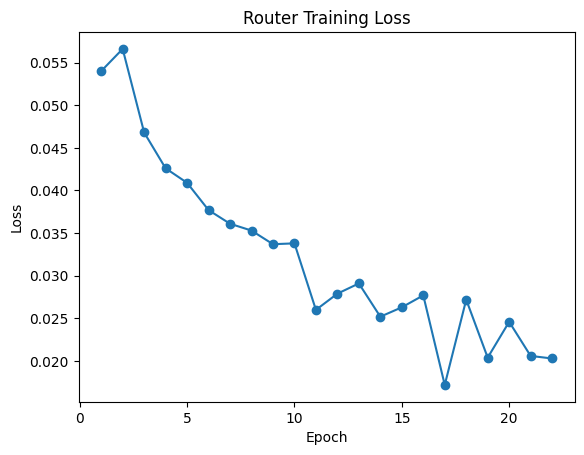

In [15]:
plt.figure()
plt.plot(epochs, loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Router Training Loss")
plt.show()

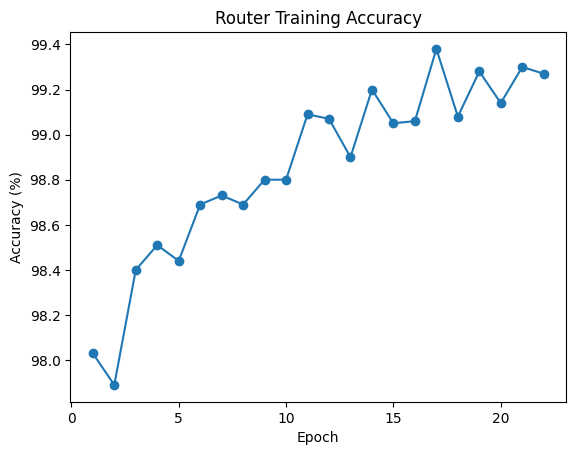

In [16]:
plt.figure()
plt.plot(epochs, acc, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Router Training Accuracy")
plt.show()

## CNN Model

In [17]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.features(x)

cnn_model = SimpleCNN().to(device)

In [20]:
import matplotlib.pyplot as plt

def train_cnn(train_loader, test_loader, num_epochs=30, patience=5, save_path="best_cnn.pth"):

    best_mae = float('inf')
    epochs_no_improve = 0

    train_losses = []
    train_maes = []
    val_maes = []

    for epoch in range(1, num_epochs+1):

        # ------------------
        # Training
        # ------------------
        cnn_model.train()
        total_loss = 0
        train_mae = 0

        for imgs, density, _ in tqdm(train_loader, desc=f"Train Epoch {epoch}/{num_epochs}"):

            imgs = imgs.to(device)
            density = density.to(device)

            cnn_optimizer.zero_grad()

            outputs = cnn_model(imgs)
            loss = density_loss(outputs, density)

            loss.backward()
            cnn_optimizer.step()

            total_loss += loss.item() * imgs.size(0)

            pred_count = outputs.sum(dim=[1,2,3])
            gt_count = density.sum(dim=[1,2,3])
            train_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_train_mae = train_mae / len(train_loader.dataset)

        train_losses.append(avg_loss)
        train_maes.append(avg_train_mae)

        # ------------------
        # Validation
        # ------------------
        cnn_model.eval()
        val_mae = 0

        with torch.no_grad():
            for imgs, density, _ in tqdm(test_loader, desc=f"Val Epoch {epoch}/{num_epochs}"):

                imgs = imgs.to(device)
                density = density.to(device)

                outputs = cnn_model(imgs)

                pred_count = outputs.sum(dim=[1,2,3])
                gt_count = density.sum(dim=[1,2,3])

                val_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_val_mae = val_mae / len(test_loader.dataset)
        val_maes.append(avg_val_mae)

        print(f"Epoch {epoch:02d}: Loss={avg_loss:.4f} | Train MAE={avg_train_mae:.2f} | Val MAE={avg_val_mae:.2f}")

        # Save best model
        if avg_val_mae < best_mae:
            best_mae = avg_val_mae
            epochs_no_improve = 0
            torch.save(cnn_model.state_dict(), save_path)
            print(f"✓ Best CNN saved with Val MAE = {best_mae:.2f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs")

        # Early stopping
        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered")
            break

    print(f"\nTraining complete. Best Val MAE: {best_mae:.2f}")

    return train_losses, train_maes, val_maes

In [21]:
loss_hist, train_mae_hist, val_mae_hist = train_cnn(train_patch_loader, test_patch_loader)

Val Epoch 1/30: 100%|██████████| 563/563 [00:07<00:00, 72.24it/s]


Epoch 01: Loss=7.9729 | Train MAE=11.39 | Val MAE=9.82
✓ Best CNN saved with Val MAE = 9.82


Val Epoch 2/30: 100%|██████████| 563/563 [00:07<00:00, 73.39it/s]


Epoch 02: Loss=7.7363 | Train MAE=11.05 | Val MAE=9.73
✓ Best CNN saved with Val MAE = 9.73


Val Epoch 3/30: 100%|██████████| 563/563 [00:07<00:00, 73.85it/s]


...

Epoch 16: Loss=6.5192 | Train MAE=9.31 | Val MAE=8.49
No improvement for 3 epochs


Val Epoch 17/30: 100%|██████████| 563/563 [00:07<00:00, 72.21it/s]


Epoch 17: Loss=6.4818 | Train MAE=9.26 | Val MAE=8.85
No improvement for 4 epochs


Val Epoch 18/30: 100%|██████████| 563/563 [00:07<00:00, 72.17it/s]

Epoch 18: Loss=6.4286 | Train MAE=9.18 | Val MAE=9.34
No improvement for 5 epochs

Early stopping triggered

Training complete. Best Val MAE: 8.49


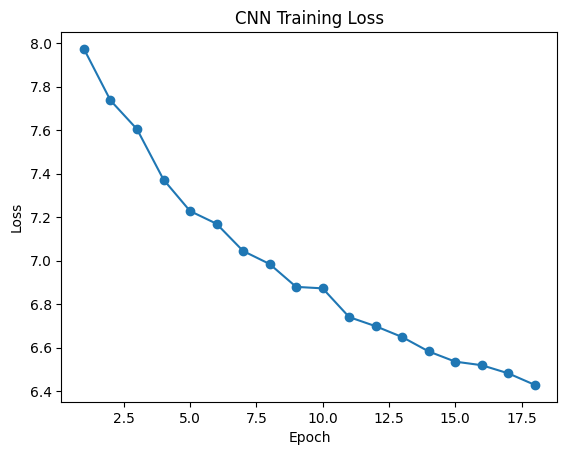

In [22]:
epochs = range(1, len(loss_hist)+1)

plt.figure()
plt.plot(epochs, loss_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.show()

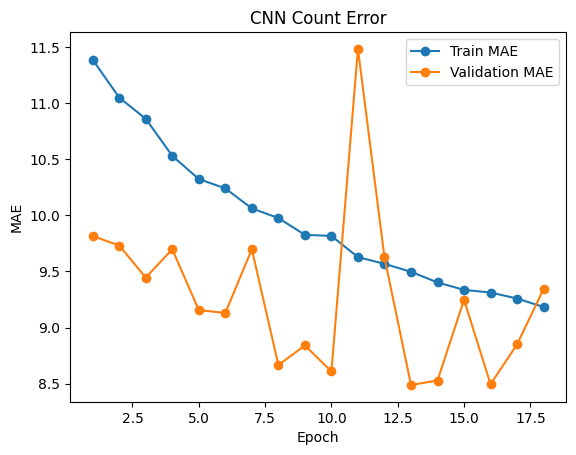

In [23]:
plt.figure()
plt.plot(epochs, train_mae_hist, marker='o', label="Train MAE")
plt.plot(epochs, val_mae_hist, marker='o', label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("CNN Count Error")
plt.legend()
plt.show()

## ViT Model

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm import create_model
from tqdm import tqdm

class FastViTDensity(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # much smaller ViT
        self.vit = create_model(
            "vit_tiny_patch16_224",
            pretrained=pretrained,
            num_classes=0
        )

        embed_dim = self.vit.num_features   # 192

        # density head with ReLU at the end
        self.density_head = nn.Sequential(
            nn.Conv2d(embed_dim, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, 1),
            nn.ReLU(inplace=True)  # ✅ Force non-negative outputs
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # ViT expects 224×224
        x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)

        # get patch tokens
        x = self.vit.patch_embed(x)
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x = self.vit.pos_drop(x + self.vit.pos_embed)

        for blk in self.vit.blocks:
            x = blk(x)

        x = self.vit.norm(x)

        # remove CLS token
        x = x[:,1:,:]

        # reshape tokens → spatial grid
        x = x.transpose(1,2).reshape(B, 192, 14, 14)

        density = self.density_head(x)

        # upscale to original patch size
        density = F.interpolate(density, size=(H,W), mode='bilinear', align_corners=False)

        return density


# Initialize model
vit_model = FastViTDensity().to(device)

# Optimizer with LOWER learning rate
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=1e-6)  # ✅ Changed from 1e-5


def train_vit(train_loader, test_loader, num_epochs=30, patience=5, save_path="best_vit.pth"):
    best_mae = float('inf')
    epochs_no_improve = 0

    train_losses = []
    train_maes = []
    val_maes = []

    for epoch in range(1, num_epochs+1):

        # ------------------
        # Training
        # ------------------
        vit_model.train()
        total_loss = 0
        train_mae = 0

        for imgs, density, _ in tqdm(train_loader, desc=f"Train Epoch {epoch}/{num_epochs}"):
            imgs = imgs.to(device)
            density = density.to(device)

            vit_optimizer.zero_grad()

            outputs = vit_model(imgs)
            loss = density_loss(outputs, density)

            loss.backward()

            # ✅ Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(vit_model.parameters(), max_norm=1.0)

            vit_optimizer.step()

            total_loss += loss.item() * imgs.size(0)

            pred_count = outputs.sum(dim=[1,2,3])
            gt_count = density.sum(dim=[1,2,3])
            train_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_train_mae = train_mae / len(train_loader.dataset)

        train_losses.append(avg_loss)
        train_maes.append(avg_train_mae)

        # ------------------
        # Validation
        # ------------------
        vit_model.eval()
        val_mae = 0

        with torch.no_grad():
            for imgs, density, _ in tqdm(test_loader, desc=f"Val Epoch {epoch}/{num_epochs}"):
                imgs = imgs.to(device)
                density = density.to(device)

                outputs = vit_model(imgs)

                pred_count = outputs.sum(dim=[1,2,3])
                gt_count = density.sum(dim=[1,2,3])

                val_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_val_mae = val_mae / len(test_loader.dataset)
        val_maes.append(avg_val_mae)

        print(f"Epoch {epoch:02d}: Loss={avg_loss:.4f} | Train MAE={avg_train_mae:.2f} | Val MAE={avg_val_mae:.2f}")

        # Save best model
        if avg_val_mae < best_mae:
            best_mae = avg_val_mae
            epochs_no_improve = 0
            torch.save(vit_model.state_dict(), save_path)
            print(f"✓ Best ViT saved with Val MAE = {best_mae:.2f}")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs")

        # Early stopping
        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered")
            break

    print(f"\nTraining complete. Best Val MAE: {best_mae:.2f}")

    return train_losses, train_maes, val_maes


# Train the model
train_losses, train_maes, val_maes = train_vit(
    train_patch_loader,
    test_patch_loader,
    num_epochs=30,
    patience=5,
    save_path="best_vit.pth"
)

Val Epoch 1/30: 100%|██████████| 563/563 [00:23<00:00, 23.99it/s]


Epoch 01: Loss=309.5080 | Train MAE=442.14 | Val MAE=14.78
✓ Best ViT saved with Val MAE = 14.78


Val Epoch 2/30: 100%|██████████| 563/563 [00:23<00:00, 24.28it/s]


Epoch 02: Loss=12.0941 | Train MAE=17.28 | Val MAE=14.71
✓ Best ViT saved with Val MAE = 14.71


Val Epoch 3/30: 100%|██████████| 563/563 [00:23<00:00, 24.10it/s]


...

Epoch 28: Loss=2.0400 | Train MAE=2.91 | Val MAE=4.73
✓ Best ViT saved with Val MAE = 4.73


Val Epoch 29/30: 100%|██████████| 563/563 [00:23<00:00, 24.27it/s]


Epoch 29: Loss=1.9925 | Train MAE=2.85 | Val MAE=4.74
No improvement for 1 epochs


Val Epoch 30/30: 100%|██████████| 563/563 [00:22<00:00, 24.53it/s]


Epoch 30: Loss=1.9488 | Train MAE=2.78 | Val MAE=4.72
✓ Best ViT saved with Val MAE = 4.72

Training complete. Best Val MAE: 4.72


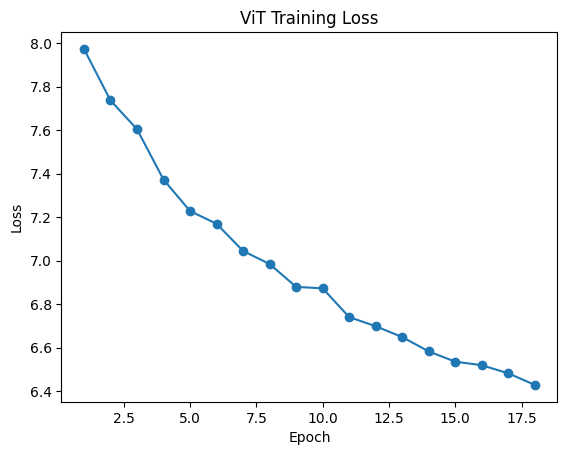

In [39]:
epochs = range(1, len(loss_hist)+1)

plt.figure()
plt.plot(epochs, loss_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training Loss")
plt.show()

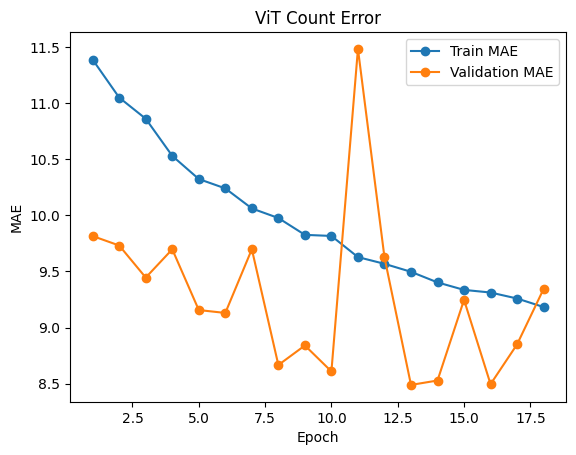

In [40]:
plt.figure()
plt.plot(epochs, train_mae_hist, marker='o', label="Train MAE")
plt.plot(epochs, val_mae_hist, marker='o', label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("ViT Count Error")
plt.legend()
plt.show()

## Hybrid Model - TRAINABLE VERSION

In [41]:
# Load best pre-trained components
router.load_state_dict(torch.load("best_router.pth"))
cnn_model.load_state_dict(torch.load("best_cnn.pth"))
vit_model.load_state_dict(torch.load("best_vit.pth"))

# Freeze router (we only want to route, not retrain it)
for p in router.parameters():
    p.requires_grad = False
router.eval()

Router(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [42]:
class HybridDensity(nn.Module):
    """Trainable hybrid model with router-based selection"""
    def __init__(self, cnn_model, vit_model, router_model):
        super().__init__()
        self.cnn = cnn_model
        self.vit = vit_model
        self.router = router_model

        # Learnable fusion weights for uncertain cases
        self.fusion_weights = nn.Parameter(torch.tensor([0.5, 0.5]))

    def forward(self, x, confidence_threshold=0.75):
        """
        Args:
            x: batch of images [B, 3, H, W]
            confidence_threshold: threshold for router confidence
        Returns:
            density map [B, 1, H, W]
        """
        B = x.size(0)

        # Get router predictions
        with torch.no_grad():
            class_logits = self.router(x)
            confs = F.softmax(class_logits, dim=1)
            max_confs, classes = confs.max(dim=1)

        # Compute both CNN and ViT outputs (always, for gradient flow)
        cnn_out = self.cnn(x)
        vit_out = self.vit(x)

        # Normalized fusion weights
        w = F.softmax(self.fusion_weights, dim=0)

        # Create masks for routing
        high_conf = max_confs > confidence_threshold
        use_cnn = (classes == 1) & high_conf  # low density
        use_vit = (classes == 2) & high_conf  # high density
        use_empty = (classes == 0) & high_conf  # empty
        use_fusion = ~high_conf  # low confidence -> fuse

        # Build output using differentiable operations
        output = torch.zeros_like(cnn_out)

        for i in range(B):
            if use_empty[i]:
                output[i] = 0  # empty patch
            elif use_cnn[i]:
                output[i] = cnn_out[i]
            elif use_vit[i]:
                output[i] = vit_out[i]
            else:  # fusion
                output[i] = w[0] * cnn_out[i] + w[1] * vit_out[i]

        return output

hybrid_model = HybridDensity(cnn_model, vit_model, router).to(device)

In [43]:
# Only optimize CNN, ViT, and fusion weights (router is frozen)
hybrid_optimizer = torch.optim.Adam(
    list(hybrid_model.cnn.parameters()) +
    list(hybrid_model.vit.parameters()) +
    [hybrid_model.fusion_weights],
    lr=1e-5
)

train_mae_history = []
val_mae_history = []

def train_hybrid(train_loader, test_loader, num_epochs=20, save_path="best_hybrid.pth"):

    best_mae = float('inf')

    for epoch in range(1, num_epochs+1):

        # -------- Training --------
        hybrid_model.train()
        total_loss = 0
        train_mae = 0

        for imgs, density, _ in tqdm(train_loader, desc=f"Train Epoch {epoch}/{num_epochs}"):

            imgs = imgs.to(device)
            density = density.to(device)

            hybrid_optimizer.zero_grad()

            outputs = hybrid_model(imgs)
            loss = density_loss(outputs, density)

            loss.backward()
            hybrid_optimizer.step()

            total_loss += loss.item() * imgs.size(0)

            pred_count = outputs.sum(dim=[1,2,3])
            gt_count = density.sum(dim=[1,2,3])

            train_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_train_mae = train_mae / len(train_loader.dataset)

        train_mae_history.append(avg_train_mae)

        # -------- Validation --------
        hybrid_model.eval()
        val_mae = 0

        with torch.no_grad():
            for imgs, density, _ in tqdm(test_loader, desc=f"Val Epoch {epoch}/{num_epochs}"):

                imgs = imgs.to(device)
                density = density.to(device)

                outputs = hybrid_model(imgs)

                pred_count = outputs.sum(dim=[1,2,3])
                gt_count = density.sum(dim=[1,2,3])

                val_mae += torch.abs(pred_count - gt_count).sum().item()

        avg_val_mae = val_mae / len(test_loader.dataset)

        val_mae_history.append(avg_val_mae)

        print(f"Epoch {epoch:02d}: Loss={avg_loss:.4f} | Train MAE={avg_train_mae:.2f} | Val MAE={avg_val_mae:.2f}")
        print(f"Fusion weights: CNN={hybrid_model.fusion_weights[0].item():.3f}, ViT={hybrid_model.fusion_weights[1].item():.3f}")

        # Save best model
        if avg_val_mae < best_mae:
            best_mae = avg_val_mae
            torch.save(hybrid_model.state_dict(), save_path)
            print(f"✓ Best Hybrid Model Saved (Val MAE = {best_mae:.2f})")

    print(f"\nTraining complete. Best Val MAE: {best_mae:.2f}")

    return train_mae_history, val_mae_history


In [45]:
train_mae_hist, val_mae_hist = train_hybrid(
    train_patch_loader,
    test_patch_loader,
    num_epochs=20,
    save_path="best_hybrid.pth"
)

Val Epoch 1/20: 100%|██████████| 563/563 [00:35<00:00, 15.77it/s]


Epoch 01: Loss=2.8830 | Train MAE=4.12 | Val MAE=4.74
Fusion weights: CNN=0.499, ViT=0.501
✓ Best Hybrid Model Saved (Val MAE = 4.74)


Val Epoch 2/20: 100%|██████████| 563/563 [00:35<00:00, 15.75it/s]


Epoch 02: Loss=2.5399 | Train MAE=3.63 | Val MAE=4.56
Fusion weights: CNN=0.498, ViT=0.502
✓ Best Hybrid Model Saved (Val MAE = 4.56)


Val Epoch 3/20: 100%|██████████| 563/563 [00:35<00:00, 15.73it/s]


...

Epoch 18: Loss=1.1361 | Train MAE=1.62 | Val MAE=4.47
Fusion weights: CNN=0.482, ViT=0.518


Val Epoch 19/20: 100%|██████████| 563/563 [00:35<00:00, 15.80it/s]


Epoch 19: Loss=1.0849 | Train MAE=1.55 | Val MAE=4.36
Fusion weights: CNN=0.481, ViT=0.519
✓ Best Hybrid Model Saved (Val MAE = 4.36)


Val Epoch 20/20: 100%|██████████| 563/563 [00:35<00:00, 15.81it/s]


Epoch 20: Loss=1.0971 | Train MAE=1.57 | Val MAE=4.33
Fusion weights: CNN=0.480, ViT=0.520
✓ Best Hybrid Model Saved (Val MAE = 4.33)

Training complete. Best Val MAE: 4.33


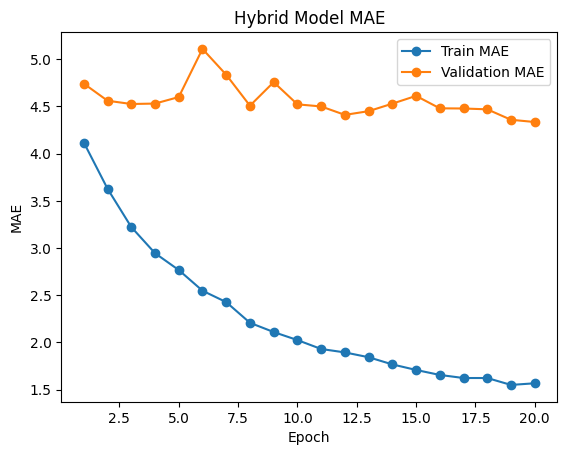

In [46]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_mae_hist)+1)

plt.figure()
plt.plot(epochs, train_mae_hist, label="Train MAE", marker='o')
plt.plot(epochs, val_mae_hist, label="Validation MAE", marker='o')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Hybrid Model MAE")
plt.legend()
plt.show()

## Evaluation

In [47]:
# Load best hybrid model
hybrid_model.load_state_dict(torch.load("best_hybrid.pth"))
hybrid_model.eval()

def evaluate_model(model, loader, model_name="Model"):
    model.eval()
    total_mae = 0
    total_mse = 0

    with torch.no_grad():
        for imgs, density, _ in tqdm(loader, desc=f"Evaluating {model_name}"):
            imgs = imgs.to(device)
            density = density.to(device)

            outputs = model(imgs) if model_name == "Hybrid" else model(imgs)

            pred_count = outputs.sum(dim=[1,2,3])
            gt_count = density.sum(dim=[1,2,3])

            total_mae += torch.abs(pred_count - gt_count).sum().item()
            total_mse += ((pred_count - gt_count) ** 2).sum().item()

    avg_mae = total_mae / len(loader.dataset)
    avg_mse = total_mse / len(loader.dataset)
    rmse = avg_mse ** 0.5

    print(f"\n{model_name} Test Results:")
    print(f"  MAE:  {avg_mae:.2f}")
    print(f"  MSE:  {avg_mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")

    return avg_mae, avg_mse, rmse

# Evaluate all models
cnn_model.load_state_dict(torch.load("best_cnn.pth"))
vit_model.load_state_dict(torch.load("best_vit.pth"))

cnn_mae, cnn_mse, cnn_rmse = evaluate_model(cnn_model, test_patch_loader, "CNN")
vit_mae, vit_mse, vit_rmse = evaluate_model(vit_model, test_patch_loader, "ViT")
hybrid_mae, hybrid_mse, hybrid_rmse = evaluate_model(hybrid_model, test_patch_loader, "Hybrid")

Evaluating CNN: 100%|██████████| 563/563 [00:07<00:00, 72.91it/s]



CNN Test Results:
  MAE:  8.49
  MSE:  266.62
  RMSE: 16.33


Evaluating ViT: 100%|██████████| 563/563 [00:23<00:00, 23.70it/s]



ViT Test Results:
  MAE:  4.72
  MSE:  97.66
  RMSE: 9.88


Evaluating Hybrid: 100%|██████████| 563/563 [00:36<00:00, 15.57it/s]


Hybrid Test Results:
  MAE:  5.47
  MSE:  111.32
  RMSE: 10.55


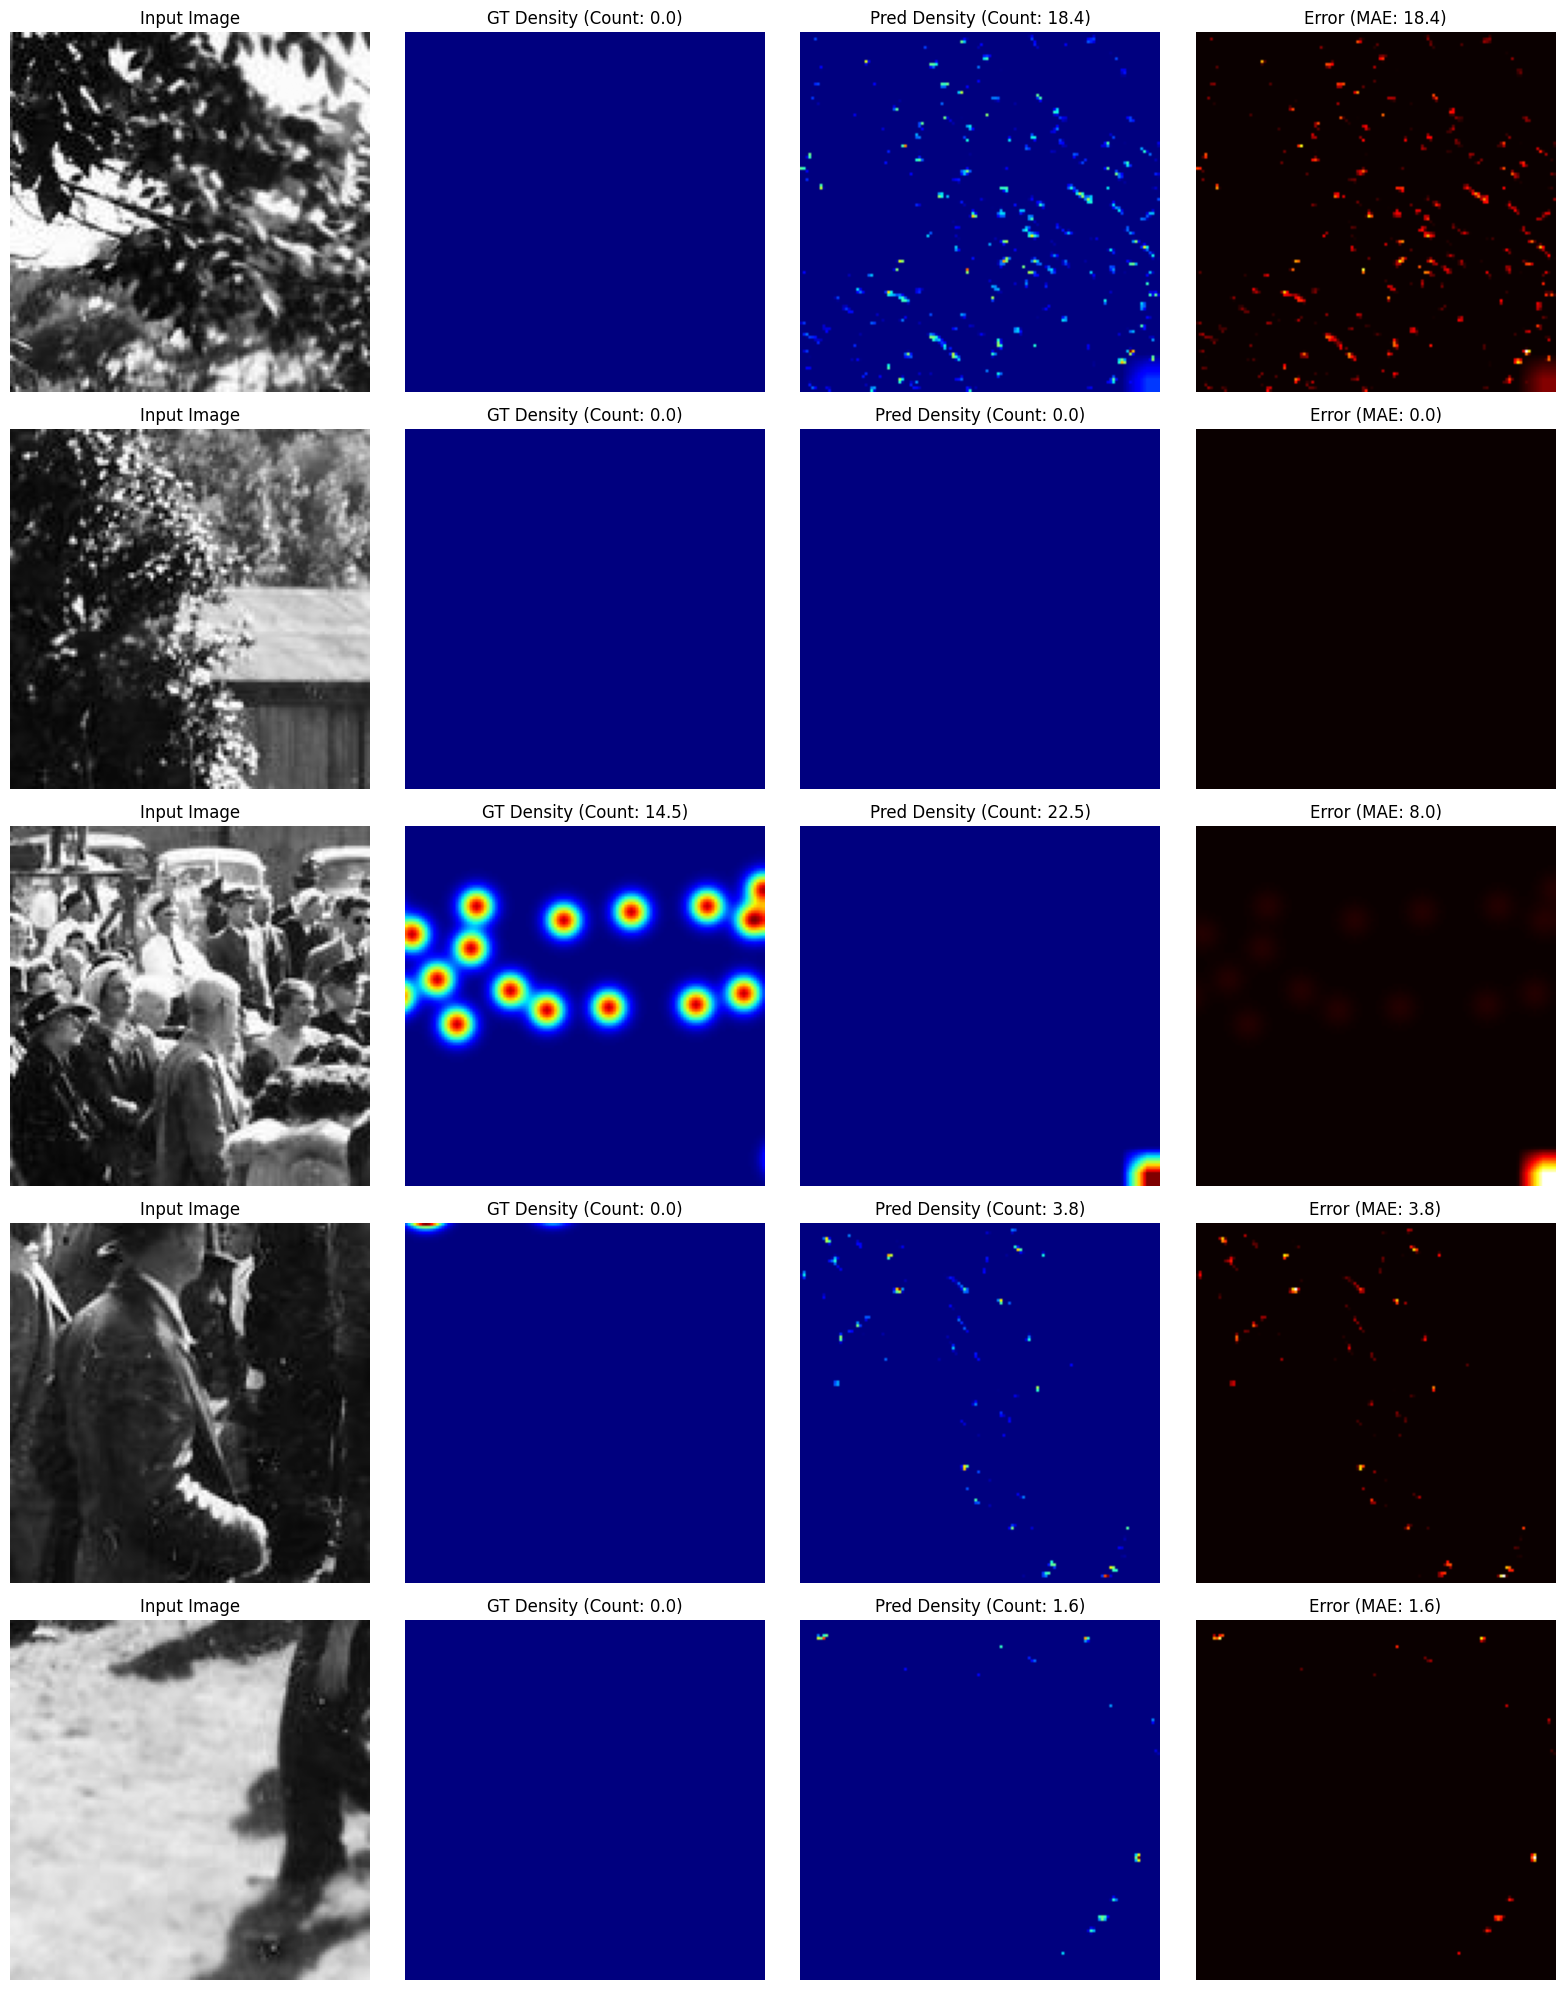

In [48]:
# Visualize some predictions
import matplotlib.pyplot as plt

def visualize_predictions(model, loader, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    with torch.no_grad():
        for idx, (imgs, density, _) in enumerate(loader):
            if idx >= num_samples:
                break

            imgs = imgs.to(device)
            density = density.to(device)

            outputs = model(imgs)

            # Take first image in batch
            img = imgs[0].cpu().permute(1,2,0).numpy()
            gt = density[0,0].cpu().numpy()
            pred = outputs[0,0].cpu().numpy()

            gt_count = density[0].sum().item()
            pred_count = outputs[0].sum().item()

            axes[idx, 0].imshow(img)
            axes[idx, 0].set_title("Input Image")
            axes[idx, 0].axis('off')

            axes[idx, 1].imshow(gt, cmap='jet')
            axes[idx, 1].set_title(f"GT Density (Count: {gt_count:.1f})")
            axes[idx, 1].axis('off')

            axes[idx, 2].imshow(pred, cmap='jet')
            axes[idx, 2].set_title(f"Pred Density (Count: {pred_count:.1f})")
            axes[idx, 2].axis('off')

            error = np.abs(gt - pred)
            axes[idx, 3].imshow(error, cmap='hot')
            axes[idx, 3].set_title(f"Error (MAE: {np.abs(gt_count - pred_count):.1f})")
            axes[idx, 3].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(hybrid_model, test_patch_loader, num_samples=5)

In [49]:
def evaluate_full_images(model, base_dataset, patch_size=128, stride=64):
    """
    Evaluate on FULL images by reconstructing from patches.

    Args:
        model: Trained model (CNN/ViT/Hybrid)
        base_dataset: ShanghaiTechDataset (train_dataset or test_dataset)
        patch_size: Size of patches
        stride: Stride for patch extraction
    """
    model.eval()
    total_mae = 0
    total_mse = 0

    with torch.no_grad():
        for img_idx in tqdm(range(len(base_dataset)), desc="Evaluating Full Images"):
            # Get full image and density map
            img, gt_density = base_dataset[img_idx]
            img = img.to(device)
            gt_density = gt_density.to(device)

            # Ground truth count
            gt_count = gt_density.sum().item()

            # Get image dimensions
            _, H, W = img.shape

            # Initialize prediction accumulator and weight map
            pred_density_map = torch.zeros((H, W), device=device)
            weight_map = torch.zeros((H, W), device=device)

            # Extract patches and predict
            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    # Extract patch
                    patch = img[:, y:y+patch_size, x:x+patch_size].unsqueeze(0)

                    # Predict density for this patch
                    patch_pred = model(patch)

                    # Accumulate predictions (handle overlaps by averaging)
                    pred_density_map[y:y+patch_size, x:x+patch_size] += patch_pred[0, 0]
                    weight_map[y:y+patch_size, x:x+patch_size] += 1

            # Average overlapping predictions
            pred_density_map = pred_density_map / weight_map.clamp(min=1)

            # Predicted count
            pred_count = pred_density_map.sum().item()

            # Compute errors
            error = abs(pred_count - gt_count)
            total_mae += error
            total_mse += error ** 2

            if img_idx < 5:  # Print first 5 examples
                print(f"Image {img_idx}: GT={gt_count:.1f}, Pred={pred_count:.1f}, Error={error:.1f}")

    # Calculate metrics
    num_images = len(base_dataset)
    avg_mae = total_mae / num_images
    avg_mse = total_mse / num_images
    rmse = avg_mse ** 0.5

    print(f"\n{'='*50}")
    print(f"FULL IMAGE Evaluation Results:")
    print(f"  MAE:  {avg_mae:.2f}")
    print(f"  MSE:  {avg_mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"{'='*50}\n")

    return avg_mae, avg_mse, rmse


# Evaluate on FULL TEST IMAGES
print("Evaluating CNN on full images...")
cnn_full_mae, _, _ = evaluate_full_images(cnn_model, test_dataset)

print("\nEvaluating ViT on full images...")
vit_full_mae, _, _ = evaluate_full_images(vit_model, test_dataset)

print("\nEvaluating Hybrid on full images...")
hybrid_full_mae, _, _ = evaluate_full_images(hybrid_model, test_dataset)

# Compare results
print("\n" + "="*60)
print("FINAL COMPARISON:")
print("="*60)
print(f"CNN:    {cnn_full_mae:.2f} MAE (full image)")
print(f"ViT:    {vit_full_mae:.2f} MAE (full image)")
print(f"Hybrid: {hybrid_full_mae:.2f} MAE (full image)")
print("="*60)

Evaluating CNN on full images...


Evaluating Full Images:   1%|          | 1/182 [00:00<00:21,  8.26it/s]

Image 0: GT=172.0, Pred=569.4, Error=397.4


Evaluating Full Images:   1%|          | 2/182 [00:00<00:23,  7.66it/s]

Image 1: GT=502.0, Pred=638.9, Error=136.9
Image 2: GT=389.0, Pred=380.5, Error=8.5


...

Image 2: GT=389.0, Pred=375.1, Error=13.9


Evaluating Full Images:   3%|▎         | 5/182 [00:04<02:21,  1.25it/s]

Image 3: GT=211.0, Pred=303.2, Error=92.2
Image 4: GT=223.0, Pred=179.9, Error=43.1


Evaluating Full Images: 100%|██████████| 182/182 [02:51<00:00,  1.06it/s]


FULL IMAGE Evaluation Results:
  MAE:  91.23
  MSE:  15025.85
  RMSE: 122.58


FINAL COMPARISON:
CNN:    184.87 MAE (full image)
ViT:    74.77 MAE (full image)
Hybrid: 91.23 MAE (full image)
